# Analyse du Ψ-score sur différents graphes sociaux

Notebook d'exploration basé sur l'article :  
**"Ranking Online Social Users by Their Influence"** - IEEE/ACM Transactions on Networking, 2021.

Le Ψ-score mesure l'influence d'un utilisateur dans un réseau social en tenant compte à la fois de sa **position dans le graphe** et de son **activité** (taux de publication λ et de re-publication μ).



## 0. Imports et configuration

In [2]:
# Si psi-score n'est pas installé, décommenter la ligne suivante :
# !pip install git+https://github.com/NouamaneA/psi-score.git --ignore-requires-python -q

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from psi_score import PsiScore

# On utilise des figures un peu plus grandes et un style propre
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

psi = PsiScore()
print("✓ Tout est chargé, on peut commencer !")


✓ Tout est chargé, on peut commencer !


## 1. Définition des graphes de test

On va travailler sur 5 topologies différentes pour voir comment la structure du réseau influence les scores :

| Graphe | Description |
|--------|-------------|
| **Toy (article)** | Le petit graphe à 4 nœuds de la Fig. 3 de l'article |
| **Anneau** | Chaque nœud suit le suivant (cycle) |
| **Étoile** | Un nœud central suivi par tous les autres |
| **Complet** | Tout le monde suit tout le monde |
| **Chaîne** | Connexions uniquement avec les voisins directs |

Dans ces graphes, le dictionnaire `adj` représente le graphe **follower** :  
`adj[i] = [j, k, ...]` signifie que les nœuds j, k… suivent i (i est leur *leader*).


In [12]:
def make_ring(n):
    """Anneau : le nœud i suit le suivant (modulo n)."""
    return {i: [(i + 1) % n] for i in range(n)}

def make_star(n):
    """Étoile : le nœud 0 est au centre, tous les autres le suivent."""
    adj = {0: list(range(1, n))}
    for i in range(1, n):
        adj[i] = [0]   # les feuilles se suivent mutuellement via le centre
    return adj

def make_complete(n):
    """Complet : tout le monde suit tout le monde."""
    return {i: [j for j in range(n) if j != i] for i in range(n)}

def make_chain(n):
    """Chaîne : connexions avec les voisins directs uniquement."""
    adj = {}
    for i in range(n):
        voisins = []
        if i > 0:
            voisins.append(i - 1)
        if i < n - 1:
            voisins.append(i + 1)
        adj[i] = voisins if voisins else [i]
    return adj

def make_toy_paper():
    """Graphe jouet Fig. 3 de l'article : A=0, B=1, C=2, D=3.
    Suivre les relations : A suivi par B,C,D ; B suivi par A,D ; etc.
    """
    return {
        0: [1, 2, 3],  # A est suivi par B, C, D
        1: [0, 3],      # B est suivi par A, D
        2: [0],          # C est suivi uniquement par A
        3: [0, 1],       # D est suivi par A, B
    }

GRAPHS = {
    "Toy (article)":  make_toy_paper(),
    "Anneau (n=6)":   make_ring(6),
    "Étoile (n=6)":   make_star(6),
    "Complet (n=5)":  make_complete(5),
    "Chaîne (n=6)":   make_chain(6),
}

def nb_noeuds(adj):
    return max(adj.keys()) + 1

# Petite vérification visuelle
for nom, adj in GRAPHS.items():
    n = nb_noeuds(adj)
    nb_liens = sum(len(v) for v in adj.values())
    print(f"  {nom:20s} → {n} nœuds, {nb_liens} liens (follower-graph)")


  Toy (article)        → 4 nœuds, 8 liens (follower-graph)
  Anneau (n=6)         → 6 nœuds, 6 liens (follower-graph)
  Étoile (n=6)         → 6 nœuds, 10 liens (follower-graph)
  Complet (n=5)        → 5 nœuds, 20 liens (follower-graph)
  Chaîne (n=6)         → 6 nœuds, 10 liens (follower-graph)


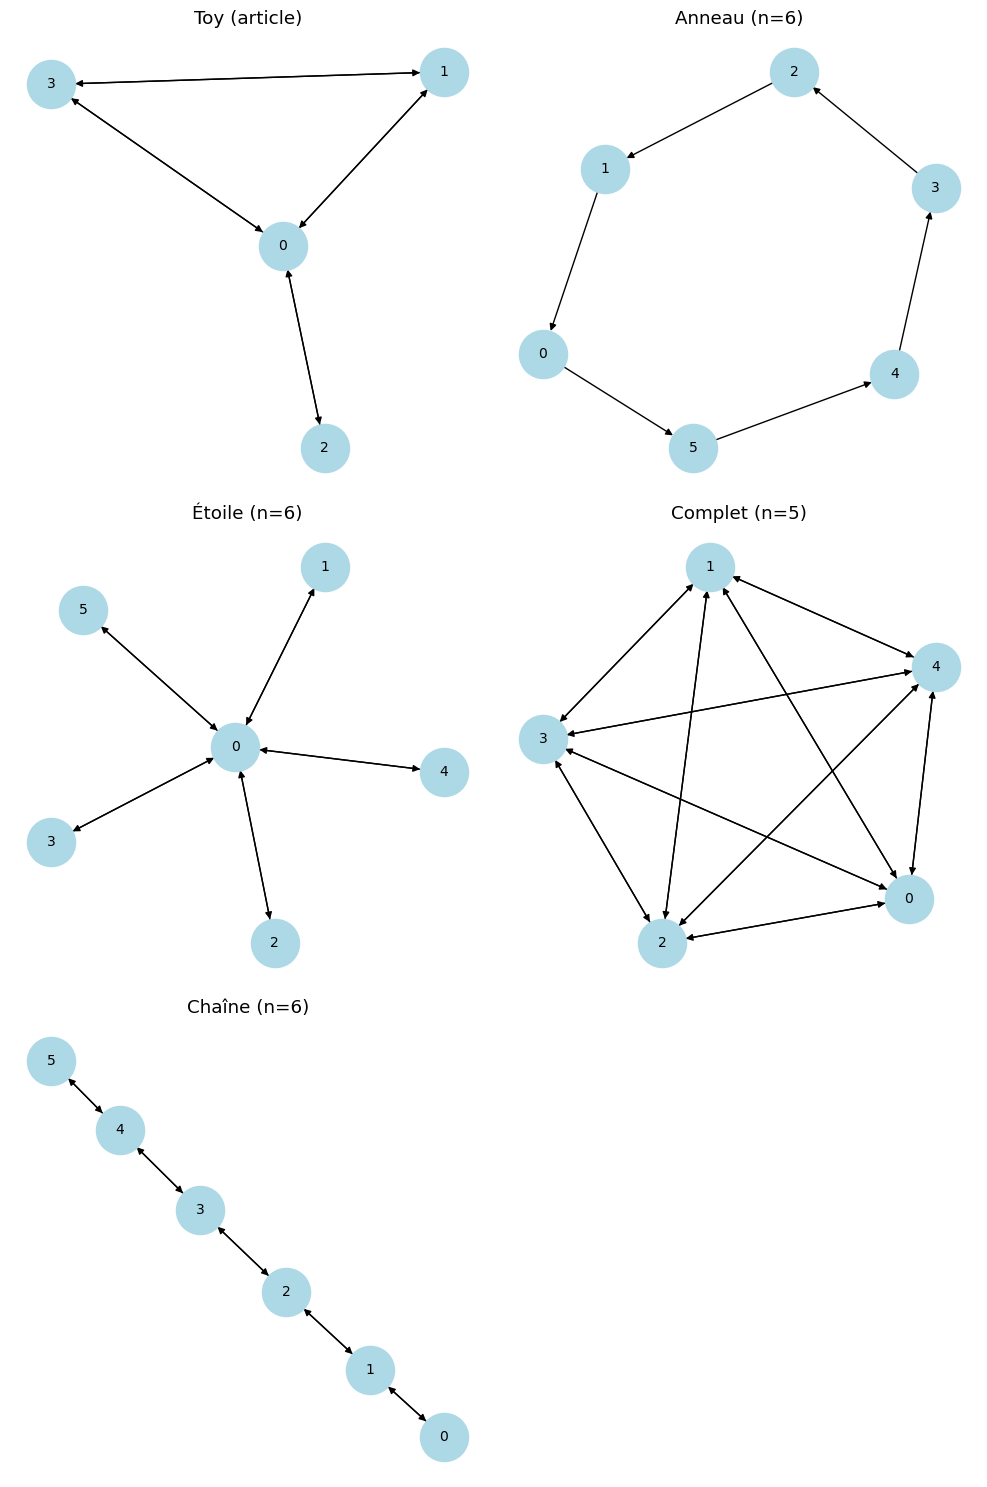

In [13]:
def build_graph(adj):
    G = nx.DiGraph()
    for leader, followers in adj.items():
        for follower in followers:
            G.add_edge(follower, leader)  # follower -> leader
    return G

# Nombre de graphes
n_graphs = len(GRAPHS)

# Grille automatique (2 colonnes)
cols = 2
rows = (n_graphs + 1) // cols

plt.figure(figsize=(10, 5 * rows))

for i, (nom, adj) in enumerate(GRAPHS.items(), 1):
    G = build_graph(adj)
    pos = nx.spring_layout(G, seed=42)

    plt.subplot(rows, cols, i)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=1200,
        node_color="lightblue",
        font_size=10,
        arrows=True
    )
    plt.title(nom)

plt.tight_layout()
plt.show()

## 2. Cas homogène

Quand tous les utilisateurs ont les mêmes λ et μ, le seul paramètre qui compte est le rapport :

$$\beta = \frac{\mu}{\lambda + \mu} \in (0, 1)$$

- β proche de **0** → les gens postent beaucoup leur propre contenu  
- β proche de **1** → les gens re-partagent surtout le contenu des autres

**Théorème 5 de l'article** : dans ce cas homogène, le Ψ̃-score coïncide exactement avec le PageRank avec facteur d'amortissement β.

On trace l'évolution des scores pour chaque nœud en fonction de β.


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

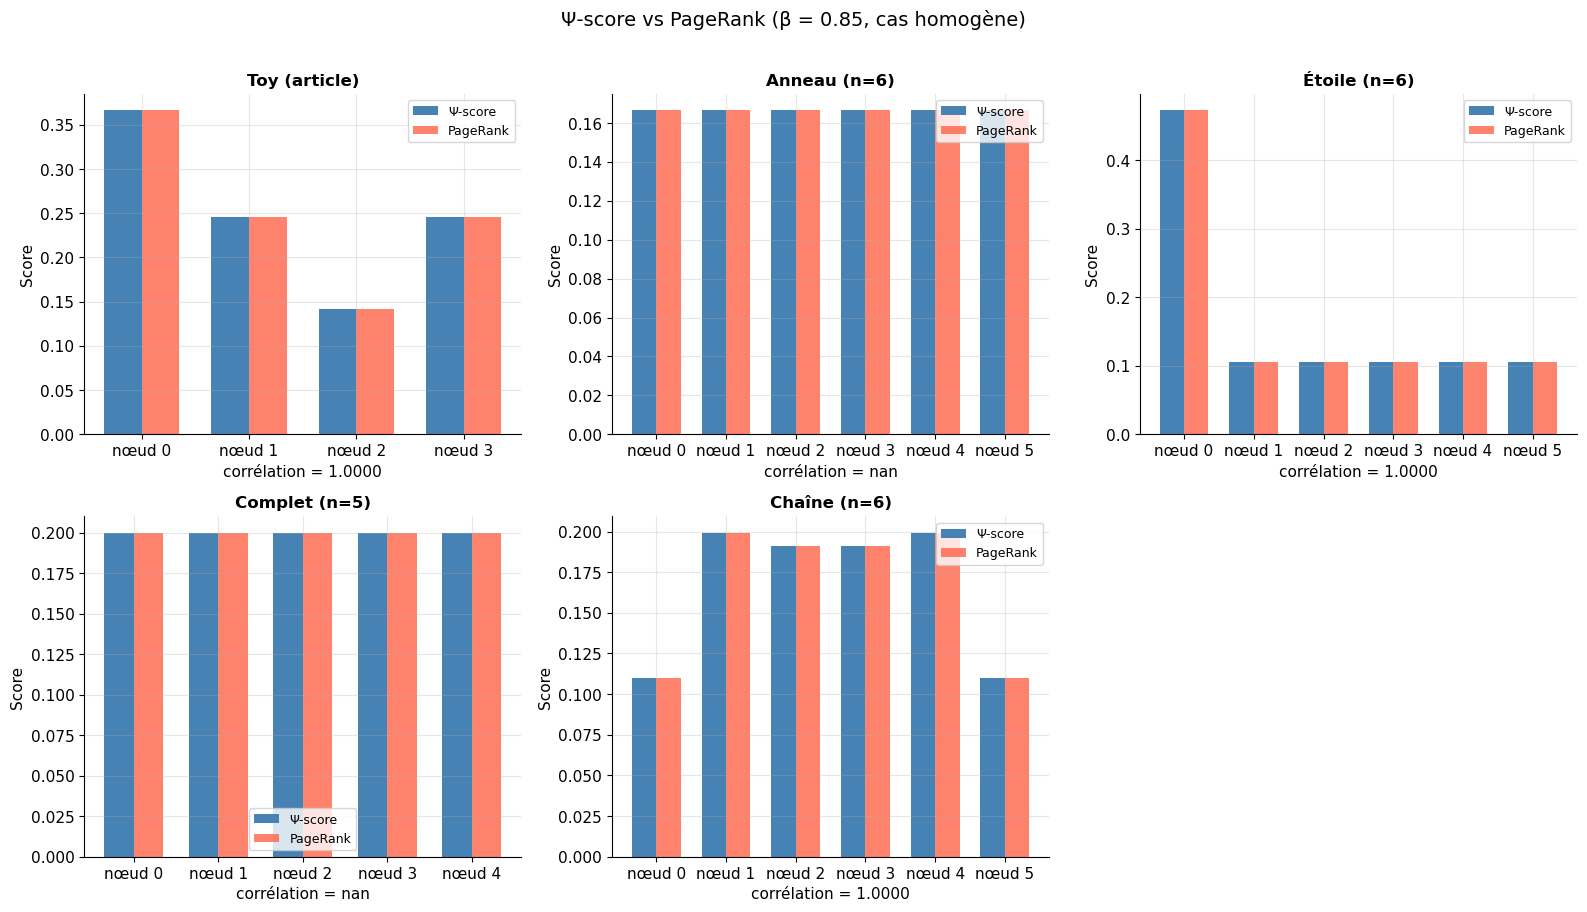

\ Théorème 5 est bien vérifié si pour chaque noeud dans chaque graphe, psyscore = pagerank


In [16]:
BETA = 0.85  # valeur classique du PageRank

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (nom, adj) in zip(axes, GRAPHS.items()):
    n = nb_noeuds(adj)
    
    lam = 1 - BETA
    mu = BETA
    
    # Ψ-score
    psi_scores = psi.fit_transform(adj, [lam]*n, [mu]*n)
    
    # PageRank
    pr_scores = pagerank_depuis_adj(adj, alpha=BETA)
    
    # Affichage côte à côte
    x = np.arange(n)
    width = 0.35
    ax.bar(x - width/2, psi_scores, width, label='Ψ-score', color='steelblue')
    ax.bar(x + width/2, pr_scores, width, label='PageRank', color='tomato', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f"nœud {i}" for i in range(n)])
    ax.set_title(nom, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    
    # Corrélation
    corr = np.corrcoef(psi_scores, pr_scores)[0, 1]
    ax.set_xlabel(f"corrélation = {corr:.4f}")

axes[-1].set_visible(False)
fig.suptitle(f"Ψ-score vs PageRank (β = {BETA}, cas homogène)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\ Théorème 5 est bien vérifié si pour chaque noeud dans chaque graphe, psyscore = pagerank")

## 3. Et si un seul nœud publie beaucoup plus que les autres ?

On fixe μ = 1 et λ = 0.5 pour tout le monde, puis on augmente progressivement λ du **nœud 0** de 0.1 à 3.

**Intuition** : poster plus souvent devrait augmenter ton influence... mais jusqu'où ? Et quel impact sur tes voisins ?


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

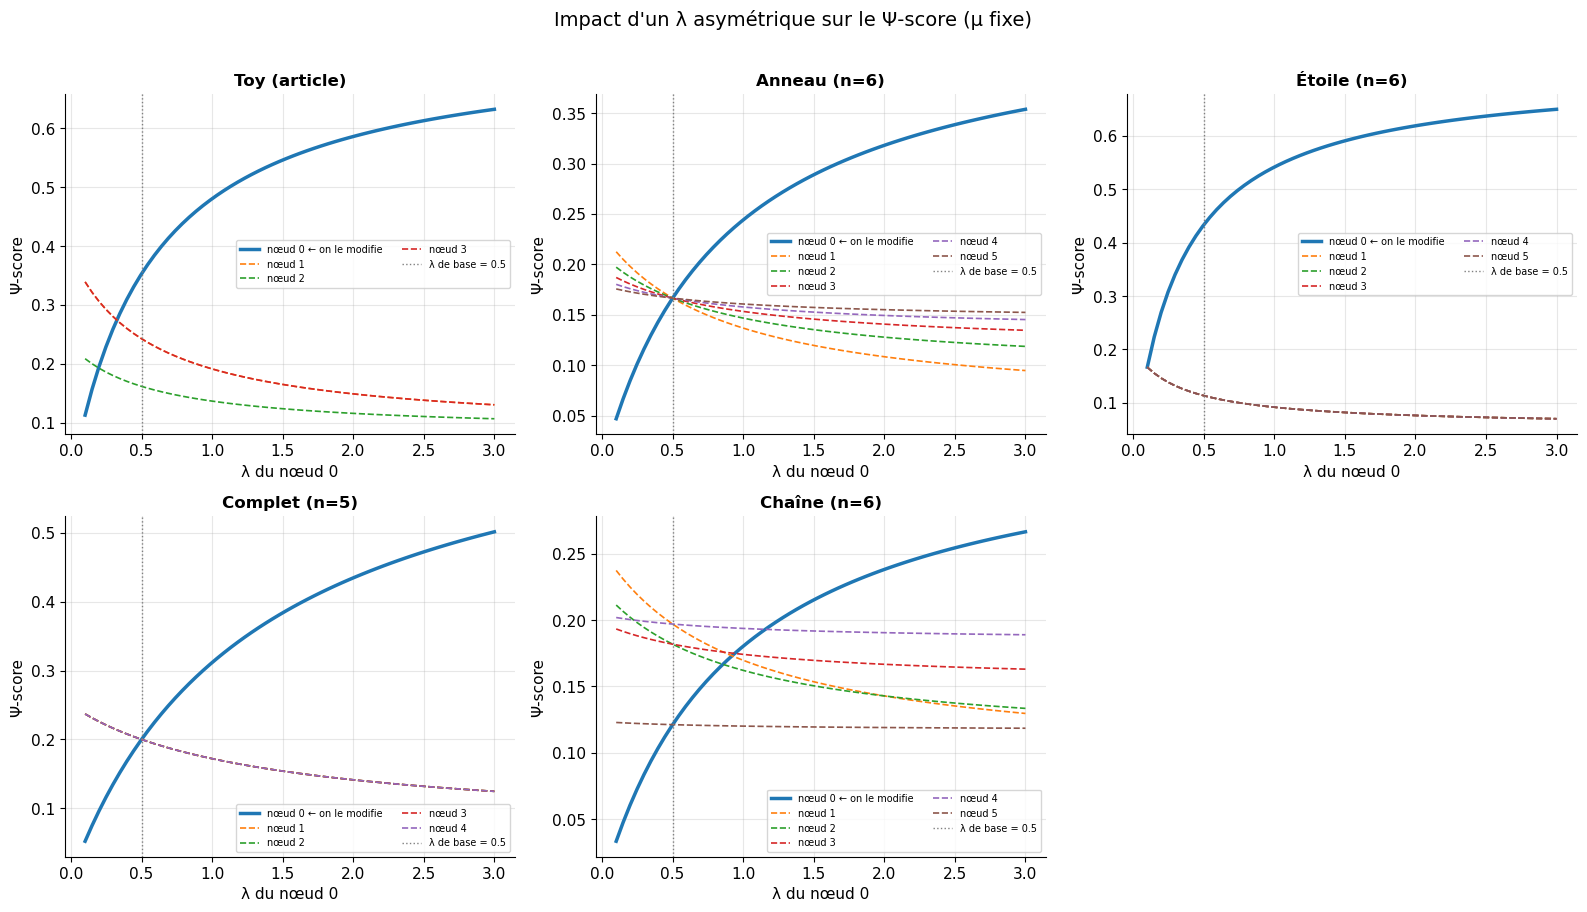

In [5]:
LAMBDA_BASE = 0.5
MU_BASE     = 1.0
lambda_values = np.linspace(0.1, 3.0, 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (nom, adj) in zip(axes, GRAPHS.items()):
    n = nb_noeuds(adj)
    cible = 0   # nœud dont on fait varier λ
    scores = []

    for lam_cible in lambda_values:
        lambdas = [LAMBDA_BASE] * n
        lambdas[cible] = lam_cible
        s = psi.fit_transform(adj, lambdas, [MU_BASE]*n)
        scores.append(s)

    scores = np.array(scores)

    for i in range(n):
        lw    = 2.5 if i == cible else 1.2
        style = "-"  if i == cible else "--"
        label = f"nœud {i} ← on le modifie" if i == cible else f"nœud {i}"
        ax.plot(lambda_values, scores[:, i], lw=lw, ls=style, label=label)

    ax.axvline(LAMBDA_BASE, color="gray", ls=":", lw=1, label=f"λ de base = {LAMBDA_BASE}")
    ax.set_title(nom, fontsize=12, fontweight="bold")
    ax.set_xlabel("λ du nœud 0")
    ax.set_ylabel("Ψ-score")
    ax.legend(fontsize=7, ncol=2)

axes[-1].set_visible(False)
fig.suptitle("Impact d'un λ asymétrique sur le Ψ-score (μ fixe)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 4. Et si un nœud re-partage beaucoup moins (ou beaucoup plus) ?

Cette fois on fait varier μ du **nœud 0** en gardant λ fixe.

Un résultat contre-intuitif de l'article : **moins un nœud re-partage, plus son score peut augmenter** — parce qu'il ne dilue pas son mur avec le contenu des autres !


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

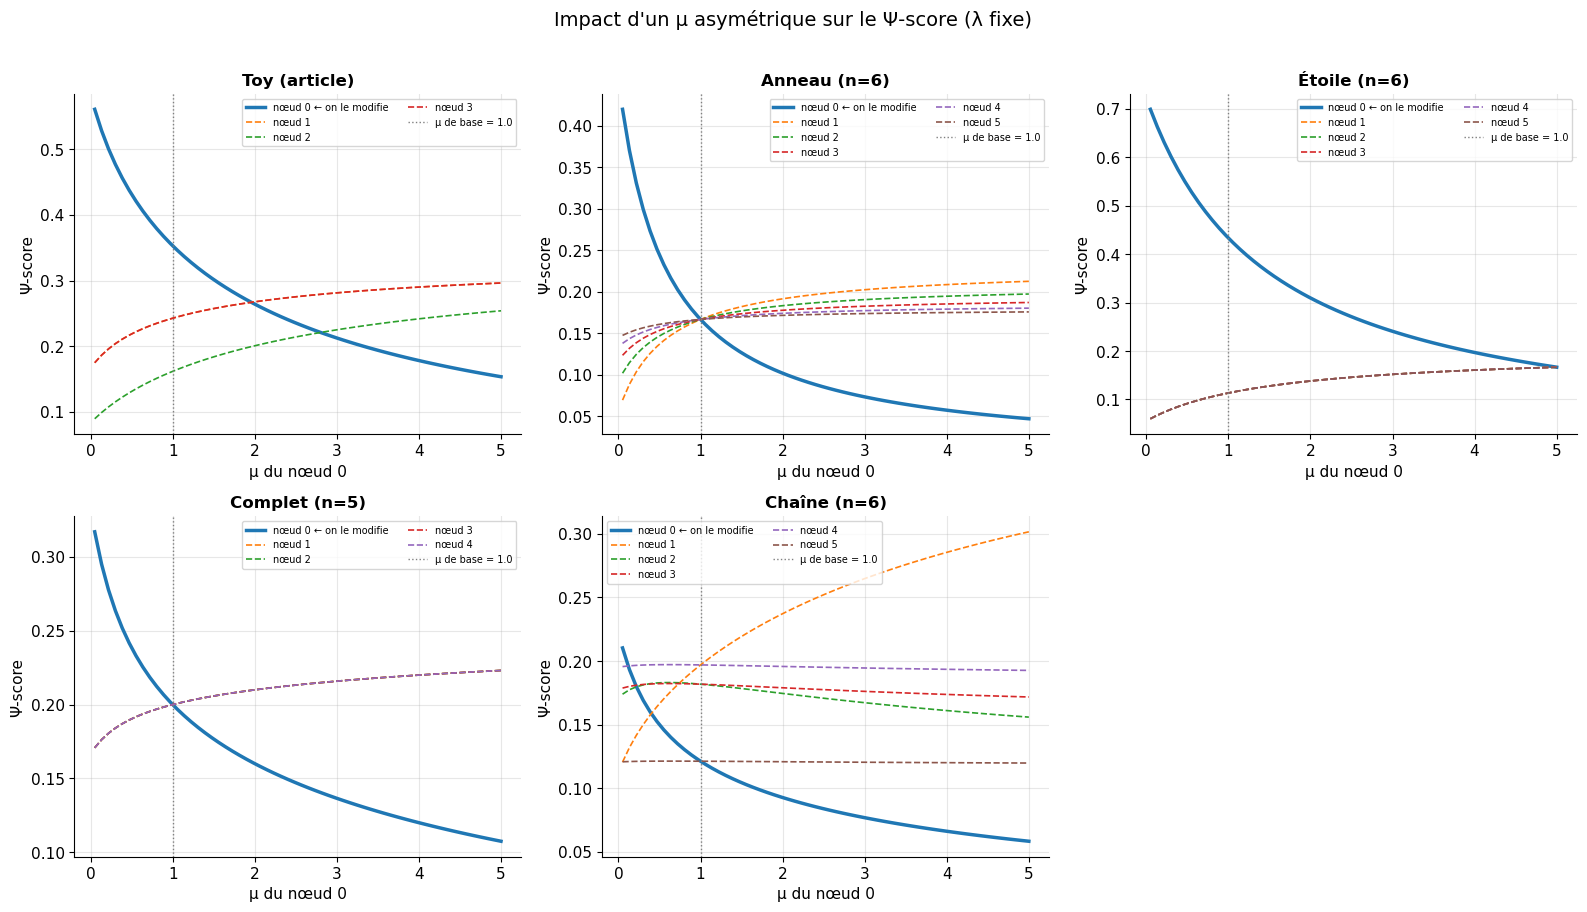

In [6]:
mu_values = np.linspace(0.05, 5.0, 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (nom, adj) in zip(axes, GRAPHS.items()):
    n = nb_noeuds(adj)
    cible = 0
    scores = []

    for mu_cible in mu_values:
        mus = [MU_BASE] * n
        mus[cible] = mu_cible
        s = psi.fit_transform(adj, [LAMBDA_BASE]*n, mus)
        scores.append(s)

    scores = np.array(scores)

    for i in range(n):
        lw    = 2.5 if i == cible else 1.2
        style = "-"  if i == cible else "--"
        label = f"nœud {i} ← on le modifie" if i == cible else f"nœud {i}"
        ax.plot(mu_values, scores[:, i], lw=lw, ls=style, label=label)

    ax.axvline(MU_BASE, color="gray", ls=":", lw=1, label=f"μ de base = {MU_BASE}")
    ax.set_title(nom, fontsize=12, fontweight="bold")
    ax.set_xlabel("μ du nœud 0")
    ax.set_ylabel("Ψ-score")
    ax.legend(fontsize=7, ncol=2)

axes[-1].set_visible(False)
fig.suptitle("Impact d'un μ asymétrique sur le Ψ-score (λ fixe)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 5. Heatmap : le Ψ-score en fonction de λ **et** μ simultanément

Sur le graphe Toy de l'article (4 nœuds A, B, C, D), on génère une heatmap pour chaque nœud : on fait varier λ et μ de ce nœud en même temps et on lit directement sur la couleur son score d'influence.

Ça permet de voir d'un coup d'œil la "zone optimale" pour maximiser son influence.


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

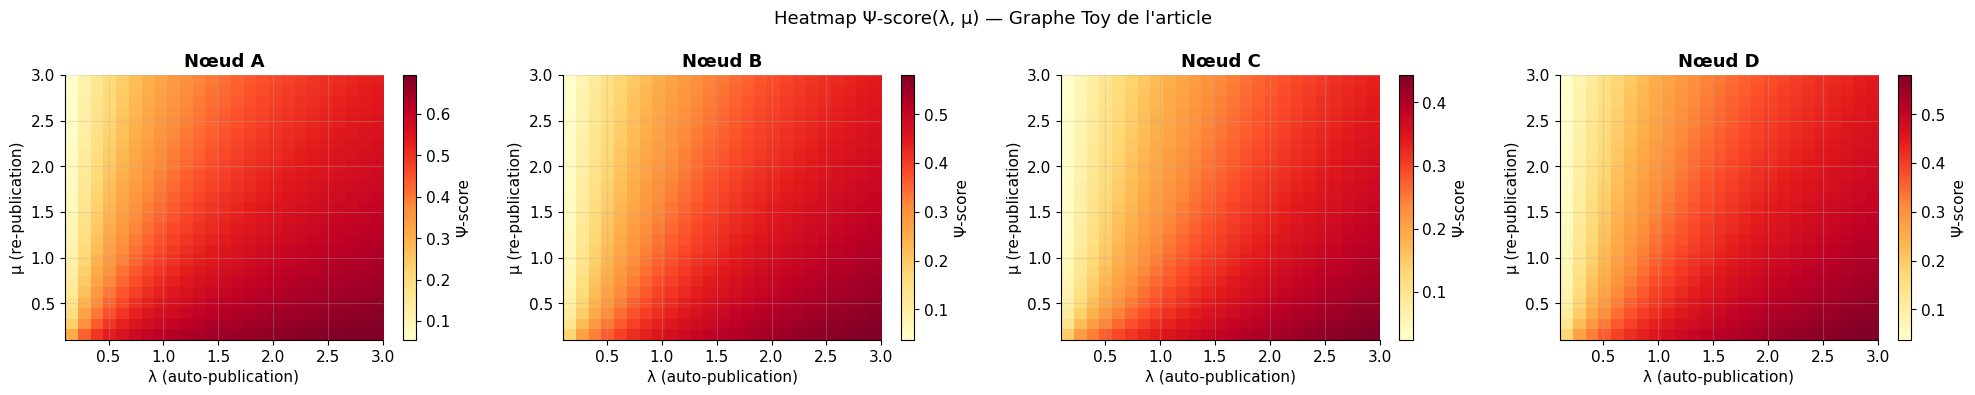

In [7]:
adj_toy   = make_toy_paper()
n_toy     = nb_noeuds(adj_toy)
noms_noeuds = ["A", "B", "C", "D"]

lambda_grid = np.linspace(0.1, 3.0, 25)   # un peu moins de points pour aller vite
mu_grid     = np.linspace(0.1, 3.0, 25)

fig, axes = plt.subplots(1, n_toy, figsize=(5 * n_toy, 4))

for idx, ax in enumerate(axes):
    heatmap = np.zeros((len(mu_grid), len(lambda_grid)))

    for j, lam in enumerate(lambda_grid):
        for k, mu in enumerate(mu_grid):
            lambdas = [LAMBDA_BASE] * n_toy
            mus     = [MU_BASE]     * n_toy
            lambdas[idx] = lam
            mus[idx]     = mu
            s = psi.fit_transform(adj_toy, lambdas, mus)
            heatmap[k, j] = s[idx]

    im = ax.imshow(
        heatmap,
        origin="lower",
        aspect="auto",
        extent=[lambda_grid[0], lambda_grid[-1], mu_grid[0], mu_grid[-1]],
        cmap="YlOrRd",
    )
    fig.colorbar(im, ax=ax, label="Ψ-score")
    ax.set_xlabel("λ (auto-publication)")
    ax.set_ylabel("μ (re-publication)")
    ax.set_title(f"Nœud {noms_noeuds[idx]}", fontsize=13, fontweight="bold")

fig.suptitle("Heatmap Ψ-score(λ, μ) — Graphe Toy de l'article", fontsize=13)
plt.tight_layout()
plt.show()


## 7. La tragédie des communs

C'est l'expérience la plus intéressante de l'article (Section VII.A).

**Scénario** : sur un graphe complet à 20 nœuds, on distingue deux types d'utilisateurs :
-**Influenceurs** : publient beaucoup (λ élevé) et re-partagent peu (μ faible)
-**Listeners** : publient peu mais re-partagent beaucoup

On commence avec tout le monde en mode "listener", puis on convertit progressivement des nœuds en "influenceurs" et on observe ce qui se passe sur les scores moyens.

**Résultat attendu** : au début les influenceurs s'en sortent mieux, mais quand ils deviennent majoritaires, tout le monde s'effondre : c'est la tragédie des communs.


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

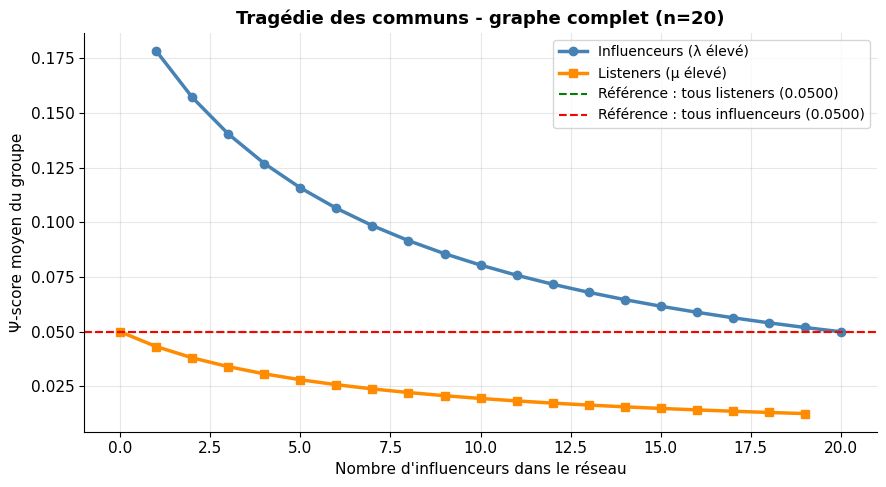

In [20]:
N     = 20
adj_c = make_complete(N) # car on veut éliminer l'effet topologique du graphe !!

# Paramètres des deux profils
LAM_INF, MU_INF = 1.0,  0.25   # influenceur : beaucoup de posts, peu de reposts
LAM_LIS, MU_LIS = 0.25, 1.0    # listener    : peu de posts, beaucoup de reposts

scores_inf = []
scores_lis = []

for n_inf in range(N + 1):
    lambdas = [LAM_INF if i < n_inf else LAM_LIS for i in range(N)]
    mus     = [MU_INF  if i < n_inf else MU_LIS  for i in range(N)]
    s = psi.fit_transform(adj_c, lambdas, mus)

    scores_inf.append(np.mean(s[:n_inf])   if n_inf > 0  else np.nan)
    scores_lis.append(np.mean(s[n_inf:])   if n_inf < N  else np.nan)

# Références : tout le monde listener, tout le monde influenceur
ref_tous_lis = psi.fit_transform(adj_c, [LAM_LIS]*N, [MU_LIS]*N).mean()
ref_tous_inf = psi.fit_transform(adj_c, [LAM_INF]*N, [MU_INF]*N).mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = list(range(N + 1))

ax.plot(x, scores_inf, "o-", color="steelblue",  lw=2.5, ms=6, label="Influenceurs (λ élevé)")
ax.plot(x, scores_lis, "s-", color="darkorange",  lw=2.5, ms=6, label="Listeners (μ élevé)")
ax.axhline(ref_tous_lis, color="green", ls="--", lw=1.5, label=f"Référence : tous listeners ({ref_tous_lis:.4f})")
ax.axhline(ref_tous_inf, color="red",   ls="--", lw=1.5, label=f"Référence : tous influenceurs ({ref_tous_inf:.4f})")

ax.set_xlabel("Nombre d'influenceurs dans le réseau")
ax.set_ylabel("Ψ-score moyen du groupe")
ax.set_title("Tragédie des communs - graphe complet (n=20)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()




## 8.  classement des nœuds avec des activités aléatoires

Pour finir, on teste sur le graphe Toy avec des λ et μ **aléatoires** pour chaque nœud (comme ce qu'on observerait sur de vraies données). On affiche le classement final et on le compare au PageRank.


  0% (0 of 500) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

Activités tirées au hasard :
  Nœud A : λ = 1.571, μ = 0.279  (β local = 0.15)
  Nœud B : λ = 0.934, μ = 1.954  (β local = 0.68)
  Nœud C : λ = 1.731, μ = 1.546  (β local = 0.47)
  Nœud D : λ = 1.425, μ = 1.594  (β local = 0.53)
 Classement Ψ-score (activités asymétriques) 
  1. Nœud A  Ψ = 0.4979
  2. Nœud D  Ψ = 0.2159
  3. Nœud C  Ψ = 0.1487
  4. Nœud B  Ψ = 0.1374
 Classement PageRank (ignore les activités)
  1. Nœud A  PR = 0.3667
  2. Nœud D  PR = 0.2459
  3. Nœud B  PR = 0.2459
  4. Nœud C  PR = 0.1414


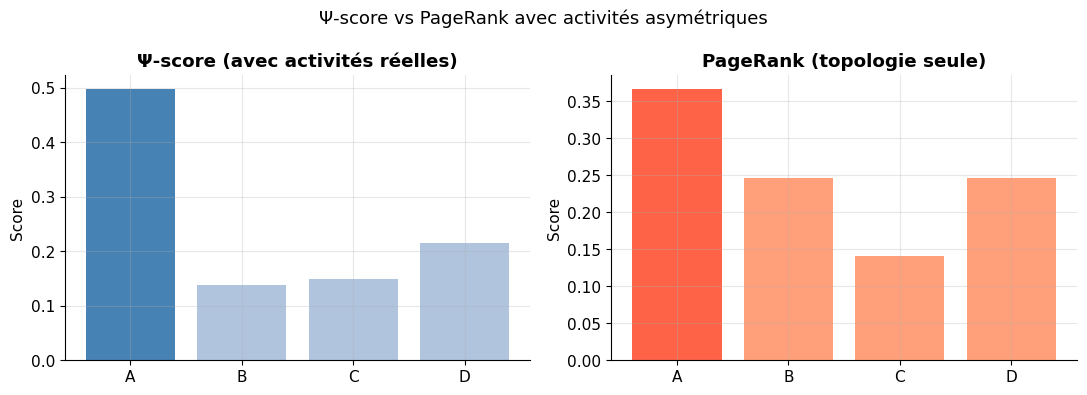


 Remarque : le classement peut être différent selon qu'on prend en compte
  les activités (Ψ) ou seulement la structure du graphe (PageRank).


In [21]:
rng = np.random.default_rng(seed=42)   # seed pour la reproductibilité

adj_toy = make_toy_paper()
n_toy   = nb_noeuds(adj_toy)
noms    = ["A", "B", "C", "D"]

# Activités aléatoires (tirées uniformément entre 0.1 et 2)
lambdas_rand = rng.uniform(0.1, 2.0, n_toy)
mus_rand     = rng.uniform(0.1, 2.0, n_toy)

print("Activités tirées au hasard :")
for i, (l, m) in enumerate(zip(lambdas_rand, mus_rand)):
    print(f"  Nœud {noms[i]} : λ = {l:.3f}, μ = {m:.3f}  (β local = {m/(l+m):.2f})")

# Calcul des scores
psi_scores = psi.fit_transform(adj_toy, lambdas_rand, mus_rand)
pr_scores  = pagerank_depuis_adj(adj_toy, alpha=0.85)

# Classements
classement_psi = np.argsort(psi_scores)[::-1]
classement_pr  = np.argsort(pr_scores)[::-1]

print(" Classement Ψ-score (activités asymétriques) ")
for rang, idx in enumerate(classement_psi, 1):
    print(f"  {rang}. Nœud {noms[idx]}  Ψ = {psi_scores[idx]:.4f}")

print(" Classement PageRank (ignore les activités)")
for rang, idx in enumerate(classement_pr, 1):
    print(f"  {rang}. Nœud {noms[idx]}  PR = {pr_scores[idx]:.4f}")

# Figure comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(noms, psi_scores, color=["steelblue" if i == classement_psi[0] else "lightsteelblue" for i in range(n_toy)])
ax1.set_title("Ψ-score (avec activités réelles)", fontweight="bold")
ax1.set_ylabel("Score")

ax2.bar(noms, pr_scores, color=["tomato" if i == classement_pr[0] else "lightsalmon" for i in range(n_toy)])
ax2.set_title("PageRank (topologie seule)", fontweight="bold")
ax2.set_ylabel("Score")

plt.suptitle("Ψ-score vs PageRank avec activités asymétriques", fontsize=13)
plt.tight_layout()
plt.show()

print("\n Remarque : le classement peut être différent selon qu'on prend en compte")
print("  les activités (Ψ) ou seulement la structure du graphe (PageRank).")


## Résumé des observations

| Expérience | Ce qu'on observe |
|---|---|
| **Ψ̃ vs PageRank** | Les deux coïncident exactement dans le cas homogène (Théorème 5 vérifié). |
| **λ asymétrique** | Publier plus augmente ton score, mais réduit celui de tes voisins directs. |
| **μ asymétrique** | Re-partager moins peut *augmenter* ton score (moins de dilution). |
| **Heatmap** | La zone "fort λ, faible μ" maximise le score pour la plupart des nœuds. |
| **Tragédie des communs** | Quand trop de nœuds adoptent la stratégie "influenceur", tout le monde s'effondre. |

**Conclusion principale** : le Ψ-score est strictement plus expressif que le PageRank car il intègre les activités réelles des utilisateurs. Un utilisateur peut avoir un rang PageRank faible mais un Ψ-score élevé s'il publie beaucoup, et vice-versa.
